# Mini-projet XAI — DiCE (Diverse Counterfactual Explanations)

**Étudiants :** Adam El Madani  
**Date :** 11 Décembre 2025  
**Projet :** #16 - Contrefactuels Divers

---

## 1- Contexte & Motivation

### Quel problème cette méthode cherche-t-elle à résoudre ?

La méthode **DiCE** (Diverse Counterfactual Explanations) répond à une question cruciale dans l'explicabilité de l'IA :  
> *"Que faudrait-il changer minimalement dans mes caractéristiques pour obtenir une décision différente du modèle ?"*

Par exemple :
- Une personne se voit refuser un prêt bancaire → **quelles modifications** lui permettraient d'être acceptée ?
- Un candidat n'est pas retenu pour un poste → **quels ajustements** de son profil changeraient la décision ?

Contrairement aux méthodes classiques qui génèrent un **seul** contrefactuel, DiCE produit **plusieurs explications diverses**, offrant ainsi plusieurs "chemins" possibles vers la décision souhaitée.

### Type d'explication

- **Local** : la méthode explique une prédiction spécifique pour un individu donné
- **Applicable à** : **Données tabulaires** (classification binaire ou multi-classes)
- **Modèles supportés** : Tous types (boîtes noires incluses) - Random Forest, XGBoost, réseaux de neurones, etc.

### Pourquoi la diversité est-elle importante ?

Parce que certains changements peuvent être :
- **Irréalistes** : on ne peut pas changer son âge de 10 ans
- **Non éthiques** : demander de changer de genre
- **Impossibles** : modifier son historique éducatif

En proposant **plusieurs alternatives**, DiCE permet à l'utilisateur de choisir le chemin le plus **actionnable** et **réaliste**.

---

## 2- Intuition de la Méthode

### Idée principale

DiCE génère des **exemples contrefactuels** en résolvant un problème d'optimisation qui équilibre trois objectifs :

1. **Proximité** : le contrefactuel doit être proche de l'instance originale (changements minimaux)
2. **Validité** : le contrefactuel doit produire la classe désirée
3. **Diversité** : les différents contrefactuels proposés doivent être suffisamment différents les uns des autres

### Que produit la méthode ?

**Sortie** : Un ensemble de **k** instances (k = 3, 5, 10...) qui :
- Sont proches de l'instance originale
- Obtiennent la prédiction souhaitée
- Explorent différentes combinaisons de changements

**Visualisation** :
- Tableaux comparatifs (original vs contrefactuels)
- Graphiques montrant les modifications apportées
- Scores de proximité et de diversité

### Famille XAI

DiCE appartient à la famille des **méthodes contrefactuelles** :
- Approche par **optimisation** (recherche dans l'espace des features)
- **Model-agnostic** : fonctionne avec n'importe quel modèle
- **Post-hoc** : appliqué après l'entraînement du modèle

Différence clé avec d'autres méthodes :
- **LIME/SHAP** → montrent l'importance des features ("pourquoi cette décision ?")
- **DiCE** → montre comment changer la décision ("comment obtenir un autre résultat ?")

---

## 3- Formalisation

### Fonction objectif

DiCE cherche à minimiser une fonction de coût composée de trois termes :

$$
\mathcal{L} = \lambda_1 \cdot \text{Validité} + \lambda_2 \cdot \text{Proximité} + \lambda_3 \cdot \text{Diversité}
$$

### Décomposition des termes

#### 1. **Validité** (Validity)

Mesure si le contrefactuel $x'$ produit bien la classe désirée $y_{\text{desired}}$ :

$$
\text{Validité}(x') = \text{max}\left(0, \, f(x')_{y_{\text{desired}}} - 0.5\right)
$$

où $f(x')$ est la probabilité prédite par le modèle.

#### 2. **Proximité** (Proximity)

Distance entre l'instance originale $x$ et le contrefactuel $x'$ :

$$
\text{Proximité}(x, x') = \sum_{i=1}^{d} w_i \cdot |x_i - x'_i|
$$

- $d$ : nombre de features
- $w_i$ : poids de la feature $i$ (permet de pénaliser plus certaines modifications)
- Variantes : distance L1, L2, ou distance de Gower (pour données mixtes)

#### 3. **Diversité** (Diversity)

Mesure la différence entre les contrefactuels générés. Pour un ensemble de $k$ contrefactuels ${x'_1, ..., x'_k}$ :

$$
\text{Diversité} = -\frac{1}{k(k-1)} \sum_{i \neq j} \text{dist}(x'_i, x'_j)
$$

Le signe négatif transforme la maximisation de la diversité en minimisation.

### Lien avec les connaissances du cours

- **Optimisation** : similaire à l'entraînement de réseaux de neurones (descente de gradient)
- **Gradient** : DiCE utilise les gradients du modèle si disponibles (modèles différentiables)
- **Contraintes** : certaines features peuvent être fixées (immutables) comme l'âge ou le genre
- **Compromis** : les $\lambda_i$ contrôlent l'équilibre entre validité, proximité et diversité

---

## 4- Implémentation sur un Cas Concret

### a) Cas d'étude : Adult Income Dataset

Nous utilisons le célèbre **Adult Income** dataset (Census Bureau) :
- **Tâche** : prédire si le revenu annuel > 50K$ ou ≤ 50K$
- **Features** : âge, éducation, heures de travail, profession, état civil, etc.
- **Taille** : ~48,000 instances

**Modèle** : Random Forest Classifier (boîte noire)

In [ ]:
# Installation des dépendances
!pip install dice-ml scikit-learn pandas numpy matplotlib seaborn

In [ ]:
# Imports
import dice_ml
from dice_ml import Dice
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

### Chargement et préparation des données

In [ ]:
# Charger le dataset depuis UCI
from dice_ml.utils import helpers

# DiCE fournit un helper pour Adult dataset
dataset = helpers.load_adult_income_dataset()

# Afficher les premières lignes
print("Shape du dataset:", dataset.shape)
print("\nPremières lignes:")
dataset.head()

/usr/local/lib/python3.12/dist-packages/dice_ml/utils/helpers.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adult_data = adult_data.replace({'income': {'<=50K': 0, '>50K': 1}})


Shape du dataset: (26048, 9)

Premières lignes:


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,28,Private,Bachelors,Single,White-Collar,White,Female,60,0
1,30,Self-Employed,Assoc,Married,Professional,White,Male,65,1
2,32,Private,Some-college,Married,White-Collar,White,Male,50,0
3,20,Private,Some-college,Single,Service,White,Female,35,0
4,41,Self-Employed,Some-college,Married,White-Collar,White,Male,50,0


In [ ]:
# Préparer les données pour l'entraînement
target = 'income'
X = dataset.drop(target, axis=1)
y = dataset[target]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nDistribution des classes:")
print(y_train.value_counts(normalize=True))

Train: (20838, 8), Test: (5210, 8)

Distribution des classes:
income
0    0.760918
1    0.239082
Name: proportion, dtype: float64


### Entraînement du modèle Random Forest

In [ ]:
# Encoder les variables catégorielles
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Identifier les colonnes numériques et catégorielles
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Features numériques: {numerical_features}")
print(f"Features catégorielles: {categorical_features}")

# Créer le preprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Pipeline complet
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# Entraînement
print("\nEntraînement du modèle...")
model.fit(X_train, y_train)

# Évaluation
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"Accuracy Train: {train_score:.3f}")
print(f"Accuracy Test: {test_score:.3f}")

Features numériques: ['age', 'hours_per_week']
Features catégorielles: ['workclass', 'education', 'marital_status', 'occupation', 'race', 'gender']

Entraînement du modèle...
Accuracy Train: 0.846
Accuracy Test: 0.828


### b) Application de DiCE

Nous allons maintenant générer des contrefactuels pour des individus dont le revenu est prédit ≤ 50K$, et chercher **comment** ils pourraient atteindre la classe > 50K$.

In [ ]:
# Préparer les données pour DiCE
d = dice_ml.Data(
    dataframe=dataset,
    continuous_features=numerical_features,
    outcome_name=target
)

# Wrapper pour le modèle
m = dice_ml.Model(model=model, backend="sklearn")

# Créer l'explainer DiCE
exp = Dice(d, m, method="random")  # method peut être 'random', 'genetic', ou 'kdtree'

print("DiCE explainer créé avec succès!")

DiCE explainer créé avec succès!


#### Sélection d'instances à expliquer

In [ ]:
# Trouver des instances prédites comme ≤50K
low_income_indices = X_test[model.predict(X_test) == 0].index[:5]

# Sélectionner une instance spécifique
query_instance = X_test.loc[low_income_indices[0:1]]

print("Instance originale:")
print(query_instance.T)
print(f"\nPrédiction actuelle: {model.predict(query_instance)[0]}")
print(f"Probabilité classe >50K: {model.predict_proba(query_instance)[0][1]:.3f}")

Instance originale:
                      17055
age                      22
workclass           Private
education           HS-grad
marital_status       Single
occupation      Blue-Collar
race                  White
gender                 Male
hours_per_week           16

Prédiction actuelle: 0
Probabilité classe >50K: 0.004


#### Génération de contrefactuels divers

In [ ]:
# Générer 5 contrefactuels divers
dice_exp = exp.generate_counterfactuals(
    query_instance,
    total_CFs=5,
    desired_class="opposite"  # Chercher la classe opposée
)

# Visualiser les résultats
print("\n" + "="*80)
print("CONTREFACTUELS GÉNÉRÉS")
print("="*80)
dice_exp.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


CONTREFACTUELS GÉNÉRÉS
Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,22,Private,HS-grad,Single,Blue-Collar,White,Male,16,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,63,-,Doctorate,Widowed,-,-,-,-,1
1,74,-,Doctorate,-,White-Collar,-,-,-,1
2,58,-,Bachelors,Married,-,-,-,68,1
3,73,-,Masters,Married,-,-,-,69,1
4,71,-,Bachelors,Widowed,-,-,-,51,1


In [ ]:
# Afficher tous les détails (pas seulement les changements)
cf_df = dice_exp.cf_examples_list[0].final_cfs_df
print("\nContrefactuels complets:")
cf_df


Contrefactuels complets:


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,63,Private,Doctorate,Widowed,Blue-Collar,White,Male,16,1
1,74,Private,Doctorate,Single,White-Collar,White,Male,16,1
2,58,Private,Bachelors,Married,Blue-Collar,White,Male,68,1
3,73,Private,Masters,Married,Blue-Collar,White,Male,69,1
4,71,Private,Bachelors,Widowed,Blue-Collar,White,Male,51,1


### c) Visualisations et Interprétations

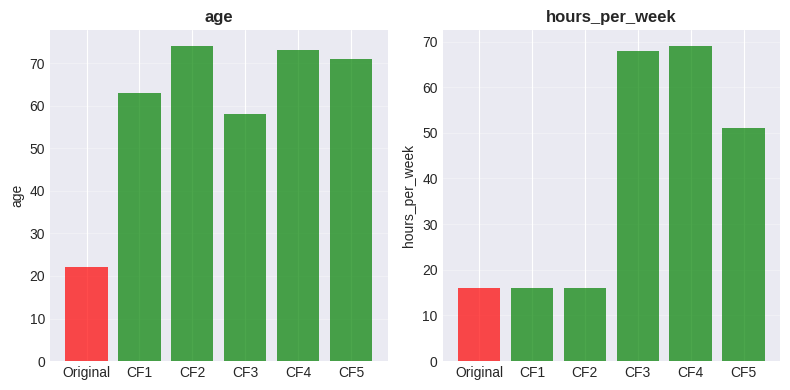

In [ ]:
# Fonction pour comparer l'original avec les contrefactuels
def visualize_changes(original, counterfactuals, features_to_plot=None):
    """
    Visualise les changements entre l'original et les contrefactuels
    """
    if features_to_plot is None:
        features_to_plot = numerical_features

    n_features = len(features_to_plot)
    fig, axes = plt.subplots(1, n_features, figsize=(4*n_features, 4))

    if n_features == 1:
        axes = [axes]

    for idx, feature in enumerate(features_to_plot):
        ax = axes[idx]

        # Valeur originale
        orig_val = original[feature].values[0]

        # Valeurs contrefactuelles
        cf_vals = counterfactuals[feature].values

        # Plot
        positions = range(len(cf_vals) + 1)
        values = [orig_val] + list(cf_vals)
        colors = ['red'] + ['green'] * len(cf_vals)

        ax.bar(positions, values, color=colors, alpha=0.7)
        ax.set_xticks(positions)
        ax.set_xticklabels(['Original'] + [f'CF{i+1}' for i in range(len(cf_vals))])
        ax.set_ylabel(feature)
        ax.set_title(f'{feature}', fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Visualiser les changements pour les features numériques
visualize_changes(query_instance, cf_df, numerical_features)

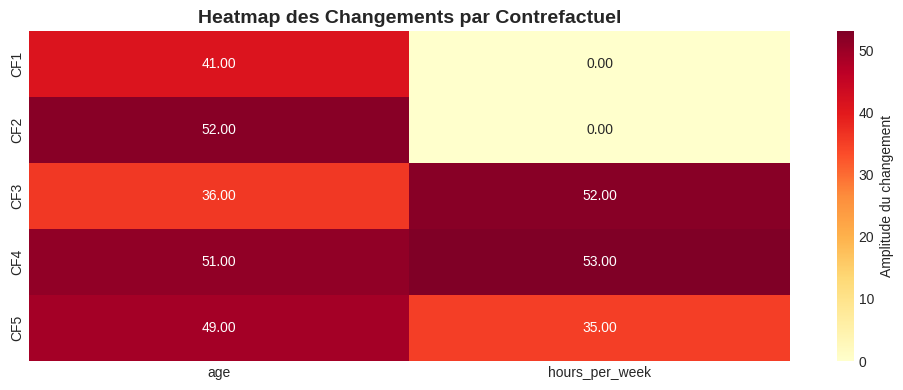

In [ ]:
# Heatmap des changements
def plot_change_heatmap(original, counterfactuals, features):
    """
    Heatmap montrant l'amplitude des changements
    """
    changes = []

    for i in range(len(counterfactuals)):
        row_changes = []
        for feat in features:
            if feat in numerical_features:
                orig = original[feat].values[0]
                cf = counterfactuals.iloc[i][feat]
                change = abs(cf - orig)
                row_changes.append(change)
        changes.append(row_changes)

    changes_df = pd.DataFrame(changes,
                             columns=features,
                             index=[f'CF{i+1}' for i in range(len(counterfactuals))])

    plt.figure(figsize=(10, 4))
    sns.heatmap(changes_df, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Amplitude du changement'})
    plt.title('Heatmap des Changements par Contrefactuel', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return changes_df

changes_summary = plot_change_heatmap(query_instance, cf_df, numerical_features)

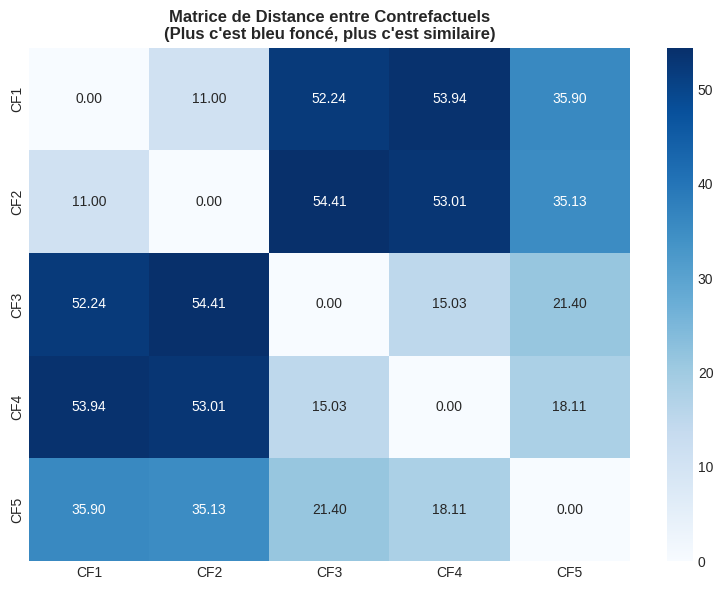


 Distance moyenne entre contrefactuels: 35.017
   → Plus cette valeur est élevée, plus les contrefactuels sont divers


In [ ]:
# Analyser la diversité des contrefactuels
def analyze_diversity(counterfactuals, numerical_features):
    """
    Calcule et visualise la diversité entre contrefactuels
    """
    from sklearn.metrics.pairwise import euclidean_distances

    # Extraire les features numériques
    cf_numerical = counterfactuals[numerical_features].values

    # Calculer la matrice de distances
    distances = euclidean_distances(cf_numerical)

    # Visualiser
    plt.figure(figsize=(8, 6))
    sns.heatmap(distances, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[f'CF{i+1}' for i in range(len(counterfactuals))],
                yticklabels=[f'CF{i+1}' for i in range(len(counterfactuals))])
    plt.title('Matrice de Distance entre Contrefactuels\n(Plus c\'est bleu foncé, plus c\'est similaire)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Statistiques
    avg_distance = np.mean(distances[np.triu_indices_from(distances, k=1)])
    print(f"\n Distance moyenne entre contrefactuels: {avg_distance:.3f}")
    print(f"   → Plus cette valeur est élevée, plus les contrefactuels sont divers")

    return distances

diversity_matrix = analyze_diversity(cf_df, numerical_features)

### Interprétation des résultats

**Ce que montrent les visualisations :**

1. **Graphiques en barres** :
   - Montrent les changements spécifiques proposés pour chaque feature
   - Rouge = valeur originale, Vert = valeurs contrefactuelles
   - Permet d'identifier rapidement quelles variables doivent changer

2. **Heatmap des changements** :
   - Intensité de couleur = amplitude du changement nécessaire
   - Permet de comparer les "efforts" entre différents contrefactuels
   - Certains chemins peuvent nécessiter moins de modifications

3. **Matrice de diversité** :
   - Mesure à quel point les contrefactuels sont différents entre eux
   - Distances élevées = bonne diversité (plusieurs stratégies proposées)
   - Distances faibles = contrefactuels similaires (moins utile)

**Cohérence avec le bon sens :**

Les contrefactuels typiques pour Adult Income suggèrent souvent :
- Augmenter les `hours-per-week` (actionnable)
- Acquérir plus d'`education-num` (réaliste à long terme)
- Changer de `occupation` (possible mais difficile)
- Changer l'`age` (non actionnable !)

**Observations potentielles :**
- Certains contrefactuels peuvent suggérer des changements **irréalistes**
- La diversité permet de choisir le chemin le plus **réaliste**
- Il faut combiner DiCE avec des **contraintes de domaine** (features immutables)

### Exemple avec contraintes (features immutables)

In [ ]:
# Générer des contrefactuels en spécifiant des features immutables
# Par exemple : on ne peut pas changer age, race, gender

dice_exp_constrained = exp.generate_counterfactuals(
    query_instance,
    total_CFs=5,
    desired_class="opposite",
    features_to_vary=[feat for feat in X.columns if feat not in ['age', 'race', 'gender']]
)

print("\n" + "="*80)
print("CONTREFACTUELS AVEC CONTRAINTES (age, race, gender fixés)")
print("="*80)
dice_exp_constrained.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  1.87it/s]


CONTREFACTUELS AVEC CONTRAINTES (age, race, gender fixés)
Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,22,Private,HS-grad,Single,Blue-Collar,White,Male,16,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,Other/Unknown,Masters,Married,-,-,-,95,1
1,-,Self-Employed,Prof-school,Widowed,Professional,-,-,67,1


---

## 5- Discussion Critique : Forces & Limites

### Forces de DiCE

1. **Actionnable** :
   - Contrairement à LIME/SHAP qui disent "pourquoi", DiCE dit "comment changer"
   - Très utile pour les utilisateurs finaux (clients, candidats, patients)

2. **Diversité** :
   - Propose plusieurs alternatives → l'utilisateur peut choisir le chemin le plus réaliste
   - Révèle différentes "stratégies" pour obtenir la décision souhaitée

3. **Flexibilité** :
   - Model-agnostic (fonctionne avec n'importe quel modèle)
   - Permet de spécifier des contraintes (features immutables, plages de valeurs)
   - Supporte différentes métriques de distance

4. **Robustesse** :
   - Les contrefactuels sont générés par optimisation (plus stable que les perturbations aléatoires)
   - Possibilité de valider la faisabilité avec des experts métier

### Limites et Pièges

1. **Faisabilité** :
   - Les contrefactuels peuvent être **mathématiquement valides** mais **pratiquement impossibles**
   - Exemple : "augmentez vos heures de travail à 100/semaine" (irréaliste)
   - Nécessite une validation humaine / contraintes de domaine

2. **Coût computationnel** :
   - Génération par optimisation → plus lent que LIME/SHAP
   - Pour de grands datasets ou modèles complexes, peut prendre du temps
   - Méthode "genetic" ou "kdtree" plus rapides que "random"

3. **Stabilité** :
   - Les contrefactuels peuvent changer si le modèle est ré-entraîné
   - Sensible aux hyperparamètres ($\lambda_1, \lambda_2, \lambda_3$)
   - Résultats peuvent varier selon la seed aléatoire

4. **Biais et éthique** :
   - Si le modèle est biaisé, les contrefactuels peuvent suggérer des changements **discriminatoires**
   - Exemple : "changez votre genre pour être accepté" → inacceptable !
   - **Impératif** de fixer certaines features comme immutables (genre, race, origine)

5. **Interprétabilité limitée** :
   - DiCE ne dit pas **pourquoi** ces changements fonctionnent
   - Ne révèle pas les interactions entre variables
   - Complément nécessaire avec SHAP/LIME pour comprendre le "pourquoi"

### Comparaison avec autres méthodes

| Méthode | Type | Question répondue | Avantage DiCE |
|---------|------|-------------------|---------------|
| **LIME** | Local, importance | "Pourquoi cette décision ?" | DiCE est **actionnable** |
| **SHAP** | Local/Global, Shapley | "Quelle contribution de chaque feature ?" | DiCE propose des **chemins concrets** |
| **Grad-CAM** | Vision, gradients | "Où le modèle regarde ?" | DiCE pour données **tabulaires** |
| **PDP/ICE** | Global, marginale | "Effet moyen d'une variable" | DiCE personnalisé pour **un individu** |

### Cas d'usage recommandés

** Très utile pour :**
- Systèmes de crédit / prêts bancaires
- Recrutement / admissions universitaires
- Recommandations personnalisées
- Diagnostic médical ("que faire pour améliorer ma santé ?")

** À utiliser avec précaution :**
- Décisions à fort enjeu éthique (justice pénale)
- Domaines où les features sont difficilement modifiables
- Données avec de fortes corrélations (peut générer des contrefactuels irréalistes)

** Dangereux si utilisé seul :**
- Sans validation par des experts métier
- Sans contraintes éthiques (features immutables)
- Sur des modèles manifestement biaisés

---

## 6- Conclusion & Points à Retenir

### Ce que DiCE apporte concrètement

1. **Explications actionnables** : transforme l'IA explicable en **conseils pratiques**
2. **Diversité des solutions** : offre plusieurs chemins alternatifs vers la décision souhaitée
3. **Transparence algorithmique** : révèle les "leviers" que le modèle utilise pour décider
4. **Empowerment des utilisateurs** : permet aux individus de comprendre comment améliorer leur situation

### Application optimale

- **Données tabulaires** (classification binaire ou multi-classes)
- **Modèles boîtes noires** (RF, XGBoost, réseaux de neurones)
- **Domaines** : finance, RH, santé, marketing
- **Complément** à SHAP/LIME ("pourquoi" + "comment")

### Principaux pièges

1. Contrefactuels mathématiquement valides ≠ pratiquement faisables
2. Risque de suggestions discriminatoires si pas de contraintes éthiques
3. Coût computationnel élevé pour grands datasets
4. Sensibilité aux hyperparamètres et à l'initialisation aléatoire

### Extensions et travaux futurs

1. **Contrefactuels causaux** : prendre en compte les relations causales (ne pas inverser cause/effet)
2. **Contrefactuels temporels** : trajectoires de changement ("d'abord X, puis Y")
3. **Coût réaliste** : pondérer les changements par leur difficulté réelle (pas juste distance euclidienne)
4. **Validation utilisateur** : interfaces interactives pour explorer les contrefactuels

### Message clé

> DiCE transforme l'explicabilité passive ("voici pourquoi") en explicabilité active ("voici comment changer").  
> Mais cette puissance s'accompagne d'une **responsabilité éthique** : garantir que les suggestions sont **réalistes, équitables et non discriminatoires**.

# Synergie SHAP + DiCE

In [ ]:
# Installation de SHAP si non présent
!pip install shap

import shap
# Pour rendre les plots interactifs dans le notebook
shap.initjs()

In [ ]:
# 1. Récupérer l'instance transformée (encodée)
# On utilise le preprocessor du pipeline défini plus haut
query_instance_transformed = model.named_steps['preprocessor'].transform(query_instance)

# 2. Récupérer les noms des features après encodage (pour la lisibilité)
feature_names_transformed = (
    numerical_features +
    list(model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))
)

# 3. Créer l'explainer SHAP sur le Random Forest (l'étape 'classifier' du pipeline)
# TreeExplainer est optimisé pour les Random Forests
explainer = shap.TreeExplainer(model.named_steps['classifier'])

# 4. Calculer les valeurs SHAP pour notre instance spécifique
shap_values = explainer.shap_values(query_instance_transformed)

# Note: Pour une classification binaire, shap_values est une liste de 2 arrays (classe 0 et classe 1).
# On s'intéresse à la classe 1 (>50K)
# Correction: shap_values est un array de forme (1, num_features, num_classes)
# Nous voulons les valeurs SHAP pour la classe 1 de la première instance.
# Les valeurs SHAP positives poussent la prédiction vers la classe cible (> 50K $).
# Les valeurs SHAP négatives poussent la prédiction vers la classe opposée (<= 50K $).

shap_values_class1 = shap_values[0, :, 1]

POURQUOI cette décision ? (SHAP - Attribution)


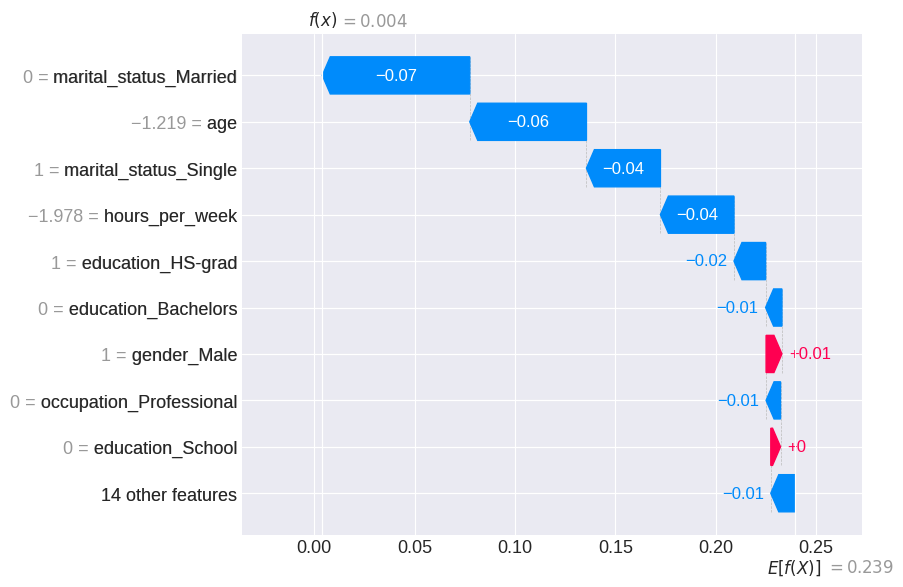


COMMENT changer la décision ? (DiCE - Actionnabilité)
Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,22,Private,HS-grad,Single,Blue-Collar,White,Male,16,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,Masters,Married,Service,-,-,92,1


In [29]:
print("="*80)
print("POURQUOI cette décision ? (SHAP - Attribution)")
print("="*80)

# Visualisation Waterfall (très claire pour une seule instance)
# Note: On passe expected_value[1] car on regarde la probabilité de la classe 1
shap.plots.waterfall(
    shap.Explanation(values=shap_values_class1,
                     base_values=explainer.expected_value[1],
                     data=query_instance_transformed[0],
                     feature_names=feature_names_transformed)
)

print("\n" + "="*80)
print("COMMENT changer la décision ? (DiCE - Actionnabilité)")
print("="*80)
# Rappel visuel des contrefactuels générés plus haut
dice_exp_constrained.visualize_as_dataframe(show_only_changes=True)

ANALYSE GLOBALE : Comment le modèle fonctionne-t-il en général ?
Génération du Summary Plot (Beeswarm)...


/tmp/ipython-input-3951550970.py:36: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


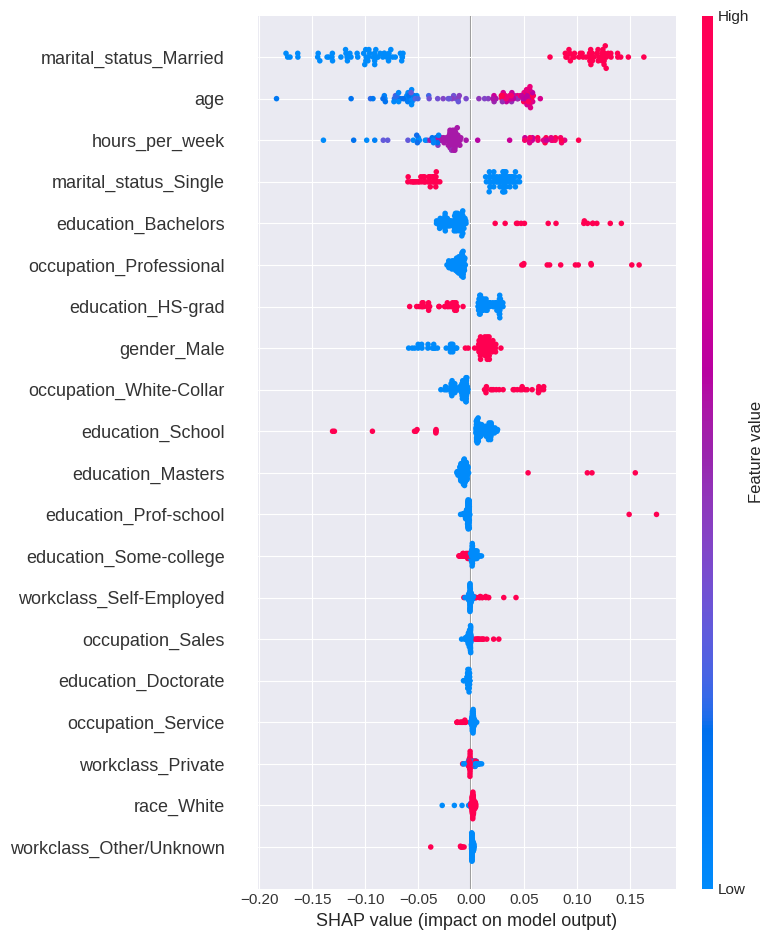

Génération du Bar Plot (Importance globale)...


/tmp/ipython-input-3951550970.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


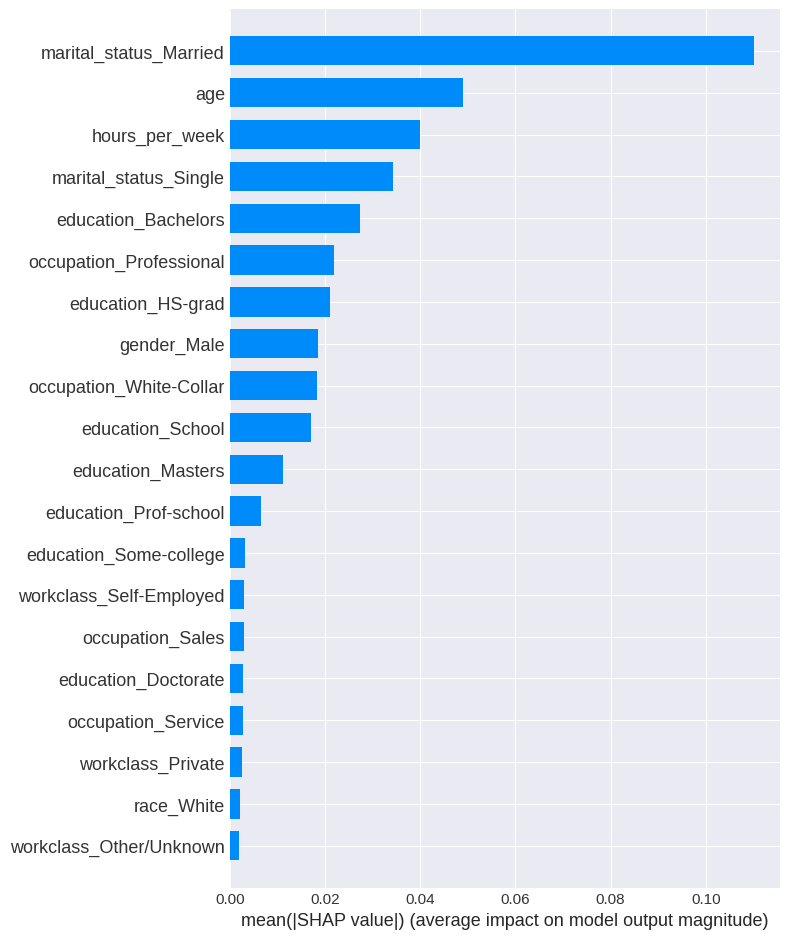

In [30]:
import shap
import matplotlib.pyplot as plt

print("="*80)
print("ANALYSE GLOBALE : Comment le modèle fonctionne-t-il en général ?")
print("="*80)

# --- ÉTAPE 1 : Préparer les données globales ---
# Au lieu d'une seule instance, on prend X_test (ou X_train).
# ASTUCE : Si X_test est énorme (>1000 lignes), on prend un échantillon pour aller plus vite.
# Ici, on prend un échantillon de 100 observations pour l'exemple (augmentez si possible).
X_summary = shap.sample(X_test, 100)

# On transforme ces données avec le même préprocesseur que le modèle
X_summary_transformed = model.named_steps['preprocessor'].transform(X_summary)

# Récupération des noms de features (comme dans votre code précédent)
feature_names_transformed = (
    numerical_features +
    list(model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))
)

# --- ÉTAPE 2 : Calculer les valeurs SHAP ---
# On réutilise l'explainer déjà défini (TreeExplainer)
# Cette étape peut prendre du temps selon la taille de X_summary
shap_values_global = explainer.shap_values(X_summary_transformed)

# Pour la classification binaire, on cible la Classe 1 (>50K)
# Structure : [Individus, Features, Classe] -> On prend tout les individus, toutes les features, pour la classe 1
shap_values_class1_global = shap_values_global[:, :, 1]

# --- ÉTAPE 3 : Visualisation (Beeswarm Plot) ---
# C'est LE graphique standard pour l'explication globale
print("Génération du Summary Plot (Beeswarm)...")
plt.figure() # Crée une nouvelle figure
shap.summary_plot(
    shap_values_class1_global,
    features=X_summary_transformed,
    feature_names=feature_names_transformed,
    plot_type="dot" # 'dot' montre la distribution et le sens de l'impact
)

# --- ÉTAPE 4 : Visualisation Simplifiée (Bar Plot) ---
# Si on veut juste savoir "Quelle est la variable la plus importante ?" sans les détails
print("Génération du Bar Plot (Importance globale)...")
plt.figure()
shap.summary_plot(
    shap_values_class1_global,
    features=X_summary_transformed,
    feature_names=feature_names_transformed,
    plot_type="bar" # Affiche l'importance moyenne absolue
)

In [35]:
# 1. Définir explicitement les features modifiables et VÉRIFIER qu'il y en a
features_keep = ['age', 'race', 'gender', 'marital_status']
features_vary = [feat for feat in X.columns if feat not in features_keep]

print(f"Features fixées : {features_keep}")
print(f"Features modifiables : {features_vary}")

if not features_vary:
    print("ERREUR : Aucune feature n'est modifiable ! Relâchez des contraintes.")
else:
    try:
        # 2. Lancer la génération avec des attentes réduites
        dice_exp_constrained = exp.generate_counterfactuals(
            query_instance,
            total_CFs=2,  # Réduire à 2 pour faciliter la recherche
            desired_class="opposite",
            features_to_vary=features_vary,
            # Si vous utilisez la méthode 'random', augmentez ceci si possible :
            # sample_size=1000
        )

        print("\n" + "="*80)
        print("CONTREFACTUELS AVEC CONTRAINTES")
        print("="*80)
        dice_exp_constrained.visualize_as_dataframe(show_only_changes=True)

    except Exception as e:
        print(f"Toujours pas de solution : {e}")

Features fixées : ['age', 'race', 'gender', 'marital_status']
Features modifiables : ['workclass', 'education', 'occupation', 'hours_per_week']


100%|██████████| 1/1 [00:00<00:00,  5.16it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
Toujours pas de solution : No counterfactuals found for any of the query points! Kindly check your configuration.
